# Superstore Sales Analyse

## Projektziel
Analyse der Verkaufs- und Profitabilitätsdaten eines fiktiven US-Einzelhandelsunternehmens,
um profitable und unprofitable Segmente zu identifizieren und konkrete
Handlungsempfehlungen abzuleiten.

## Leitfragen
- Welche Produktkategorien sind am profitabelsten?
- Welchen Effekt haben Rabatte auf den Profit?
- Wie unterscheidet sich die Performance nach Region?
- Wer sind die wichtigsten Kunden?

**Tools:** Python (Pandas, Matplotlib)  
**Datenquelle:** [Superstore Sales Dataset, Kaggle](https://www.kaggle.com/datasets/shumailazubair/superstore-sales-dataset-cleaned-for-sql-and-powerbi?select=superstore_sales.csv) - bereits bereinigte Version (keine Duplikate/fehlende Werte laut Datensatz-Beschreibung)                  
**Umfang:** 9'994 Bestellungen, 21 Spalten

In [18]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

# encoding='latin1' ist nötig, weil diese Datei Sonderzeichen enthält,
# die nicht im Standard-UTF-8-Format gespeichert sind
df = pd.read_csv('superstore_sales.csv', encoding='latin1')

# Datum als echtes Datum interpretieren (nicht als Text)
# dayfirst=True, weil das Format TT/MM/JJJJ ist (z.B. 08/11/2016 = 8. November)
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)
df['ship_date'] = pd.to_datetime(df['ship_date'], dayfirst=True)

print("Zeilen, Spalten:", df.shape)
df.head()

# Fehlende Werte checken
print("Fehlende Werte:\n", df.isnull().sum().sum(), "total")

# Duplikate checken
print("Duplikate:", df.duplicated().sum())

# Schneller Überblick über Zahlenspalten
df.describe()


Saving superstore_sales.csv to superstore_sales (1).csv
Zeilen, Spalten: (9994, 21)
Fehlende Werte:
 0 total
Duplikate: 0


,row_id,order_date,ship_date,postal_code,sales,quantity,discount,profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.873324,3.789574,0.092255,28.651891
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.000000,1.000000,0.000000,-6600.000000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.000000,2.000000,0.000000,2.000000
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.500000,3.000000,0.000000,9.000000
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,210.000000,5.000000,0.000000,29.000000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.000000,14.000000,1.000000,8400.000000
std,2885.163629,NaN,NaN,32063.693350,623.248946,2.225110,0.289401,234.255712


## 1. Data Quality Check

Bevor die Analyse beginnt, prüfe ich systematisch auf fehlende Werte, Duplikate
und logische Inkonsistenzen (z.B. Versanddatum vor Bestelldatum).

In [19]:
# ===== DATA QUALITY CHECK =====

# 1. Fehlende Werte
print("=== Fehlende Werte ===")
print(df.isnull().sum().sum(), "fehlende Werte insgesamt")

# 2. Duplikate
print("\n=== Duplikate ===")
print(df.duplicated().sum(), "Duplikate gefunden")

# 3. Ausreisser bei Profit checken (wichtig für später!)
print("\n=== Profit-Verteilung (Ausreisser-Check) ===")
print("Minimum Profit:", df['profit'].min())
print("Maximum Profit:", df['profit'].max())
print("Anzahl Aufträge mit Verlust (Profit < 0):", (df['profit'] < 0).sum())

# 4. Logik-Check: Ship Date sollte nie vor Order Date liegen
invalid_dates = df[df['ship_date'] < df['order_date']]
print("\n=== Datums-Logik-Check ===")
print(f"Fälle mit Ship Date vor Order Date: {len(invalid_dates)}")

=== Fehlende Werte ===
0 fehlende Werte insgesamt

=== Duplikate ===
0 Duplikate gefunden

=== Profit-Verteilung (Ausreisser-Check) ===
Minimum Profit: -6600
Maximum Profit: 8400
Anzahl Aufträge mit Verlust (Profit < 0): 1865

=== Datums-Logik-Check ===
Fälle mit Ship Date vor Order Date: 0


**Ergebnis:** Der Datensatz ist laut Kaggle-Beschreibung bereits bereinigt
(keine Duplikate, keine fehlenden Werte) – meine eigene Prüfung bestätigt dies.
Trotzdem finde ich einen nicht dokumentierten Datenfehler: eine Bestellung mit
sales = 0, die bei der Margin-Berechnung zu einem `-inf`-Wert führt. Diese
Zeile entferne ich für die weitere Analyse.

## 2. Neue Kennzahlen ableiten

Ich berechne zusätzliche Spalten, die für die Analyse nötig sind: Profit-Marge
in %, Jahr/Monat für Zeitreihenanalysen, Lieferzeit in Tagen, und ein lesbares
Rabatt-Label.

In [20]:
# Datenfehler entdeckt: 1 Zeile mit sales = 0 verursacht -inf bei profit_margin
# Diese Zeile wird für die Margin-Berechnung ausgeschlossen (dokumentiert!)
print("Zeile mit sales=0 gefunden:")
print(df[df['sales'] == 0][['order_id', 'category', 'sales', 'profit']])

df = df[df['sales'] != 0].copy()  # diese eine Zeile entfernen
print(f"\nNeue Zeilenanzahl nach Bereinigung: {len(df)}")
# Profit-Marge in Prozent berechnen
df['profit_margin'] = (df['profit'] / df['sales'] * 100).round(2)

# Jahr und Monat separat extrahieren (nützlich für Zeitreihen-Analysen)
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_year_month'] = df['order_date'].dt.to_period('M')

# Lieferzeit in Tagen berechnen
df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days

# Rabatt als lesbares Label (statt 0/1)
df['discount_label'] = df['discount'].map({0: 'Kein Rabatt', 1: 'Mit Rabatt'})

df.head()

Zeile mit sales=0 gefunden:
            order_id         category  sales  profit
4101  US-2017-102288  Office Supplies      0      -1

Neue Zeilenanzahl nach Bereinigung: 9993


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sales,quantity,discount,profit,profit_margin,order_year,order_month,order_year_month,shipping_days,discount_label
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,262,2,0,42,16.03,2016,11,2016-11,3,Kein Rabatt
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,732,3,0,220,30.05,2016,11,2016-11,3,Kein Rabatt
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,15,2,0,7,46.67,2016,6,2016-06,4,Kein Rabatt
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,958,5,0,-383,-39.98,2015,10,2015-10,7,Kein Rabatt
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22,2,0,3,13.64,2015,10,2015-10,7,Kein Rabatt


## 3. Profitabilität nach Kategorie & Sub-Kategorie

Frage: Welche Produktkategorien treiben den Profit — und welche verlieren Geld?

In [21]:
# ===== ANALYSE 1: Profitabilität nach Kategorie =====
category_analysis = df.groupby('category').agg(
    total_sales=('sales', 'sum'),
    total_profit=('profit', 'sum'),
    avg_margin=('profit_margin', 'mean'),
    num_orders=('order_id', 'count')
).round(2).sort_values('total_profit', ascending=False)

print("=== Profitabilität nach Kategorie ===")
print(category_analysis)

# ===== ANALYSE 2: Die unprofitabelsten Sub-Kategorien finden =====
subcategory_analysis = df.groupby('sub_category').agg(
    total_sales=('sales', 'sum'),
    total_profit=('profit', 'sum')
).round(2).sort_values('total_profit')

print("\n=== Top 5 unprofitabelste Sub-Kategorien ===")
print(subcategory_analysis.head())

=== Profitabilität nach Kategorie ===
                 total_sales  total_profit  avg_margin  num_orders
category                                                          
Technology            836221        145429       15.57        1847
Office Supplies       719127        122475       13.79        6025
Furniture             742006         18444        3.91        2121

=== Top 5 unprofitabelste Sub-Kategorien ===
              total_sales  total_profit
sub_category                           
Tables             206968        -17733
Bookcases          114879         -3479
Supplies            46679         -1187
Fasteners            3024           952
Machines           189243          3387


**Hinweis zur Zählweise:** Die folgenden Analysen verwenden `num_orders` als
Anzahl Produktzeilen (Order Lines) – der Datensatz hat 9'993 solche Zeilen,
aber nur 5'009 eindeutige Bestellungen (`order_id`), da eine Bestellung
mehrere Produkte enthalten kann. Für Fragen wie "wie viele Bestellungen gab
es" ist die Anzahl eindeutiger `order_id` die relevantere Kennzahl (siehe
Power BI Dashboard).

**Erkenntnis:** Technology bringt mit \$ 145'429 den höchsten Profit, obwohl
Office Supplies fast gleich viel Umsatz macht (\$ 719K vs. 836K). Furniture
sticht negativ heraus: Trotz \$ 742K Umsatz bleiben nur \$ 18'444 Profit übrig
– eine Marge von knapp 4%, während Technology auf über 15% kommt.

Auf Sub-Kategorie-Ebene wird klar, woran das liegt: **Tables** macht \$ 206K
Umsatz, verliert aber \$ 17'733. Bookcases verliert ebenfalls Geld (-3'479).
Beide gehören zu Furniture – das erklärt die schwache Kategorie-Marge.

## 4. Effekt von Rabatten auf den Profit

In [22]:
# ===== ANALYSE 3: Rabatt-Effekt auf Profit =====
discount_analysis = df.groupby('discount_label').agg(
    avg_profit=('profit', 'mean'),
    avg_margin=('profit_margin', 'mean'),
    num_orders=('order_id', 'count')
).round(2)

print("\n=== Rabatt vs. kein Rabatt ===")
print(discount_analysis)


=== Rabatt vs. kein Rabatt ===
                avg_profit  avg_margin  num_orders
discount_label                                    
Kein Rabatt          42.27       24.41        9072
Mit Rabatt         -105.41     -110.06         921


**Erkenntnis:** Der Unterschied ist deutlich: Bestellungen ohne Rabatt bringen
im Schnitt \$ 42 Profit pro Auftrag (24% Marge), während rabattierte
Bestellungen im Durchschnitt \$ 105 **Verlust** machen. Rabatte werden aktuell
zwar nur bei 922 von rund 9'900 Bestellungen eingesetzt, kippen aber in diesen
Fällen die Profitabilität komplett ins Negative.

## 5. Regionale Performance & Top-Kunden

In [23]:
# ===== ANALYSE 4: Performance nach Region =====
region_analysis = df.groupby('region').agg(
    total_sales=('sales', 'sum'),
    total_profit=('profit', 'sum'),
    avg_margin=('profit_margin', 'mean')
).round(2).sort_values('total_profit', ascending=False)

print("=== Performance nach Region ===")
print(region_analysis)

# ===== ANALYSE 5: Top 10 Kunden nach Umsatz =====
top_customers = df.groupby('customer_name').agg(
    total_sales=('sales', 'sum'),
    total_profit=('profit', 'sum'),
    num_orders=('order_id', 'count')
).round(2).sort_values('total_sales', ascending=False).head(10)

print("\n=== Top 10 Kunden nach Umsatz ===")
print(top_customers)

=== Performance nach Region ===
         total_sales  total_profit  avg_margin
region                                        
West          725514        108386       21.93
East          678834         91521       16.69
South         391750         46721       16.15
Central       501256         39720      -10.25

=== Top 10 Kunden nach Umsatz ===
                    total_sales  total_profit  num_orders
customer_name                                            
Sean Miller               25042         -1981          15
Tamara Chand              19050          8983          12
Raymond Buch              15117          6976          18
Tom Ashbrook              14596          4704          10
Adrian Barton             14476          5445          20
Ken Lonsdale              14175           802          29
Sanjit Chand              14145          5756          22
Hunter Lopez              12875          5623          11
Sanjit Engle              12209          2650          19
Christopher C

**Erkenntnis:** Region West ist mit \$ 108'386 Profit und der höchsten Marge
(22%) die stärkste Region, gefolgt von East. Central bleibt trotz $ 501K
Umsatz deutlich zurück (\$ 39'719 Profit, ~8% Marge).

Bei den Top-Kunden fällt ein Sonderfall auf: **Sean Miller** ist zwar der
umsatzstärkste Kunde (\$ 25'042), erzeugt aber einen Verlust von \$ 1'981 –
im Gegensatz zu Tamara Chand, die bei tieferem Umsatz (\$ 19'050) einen
soliden Profit von \$ 8'983 einbringt. Hoher Umsatz heisst hier also nicht
automatisch hoher Profit.

## 6. Visualisierung

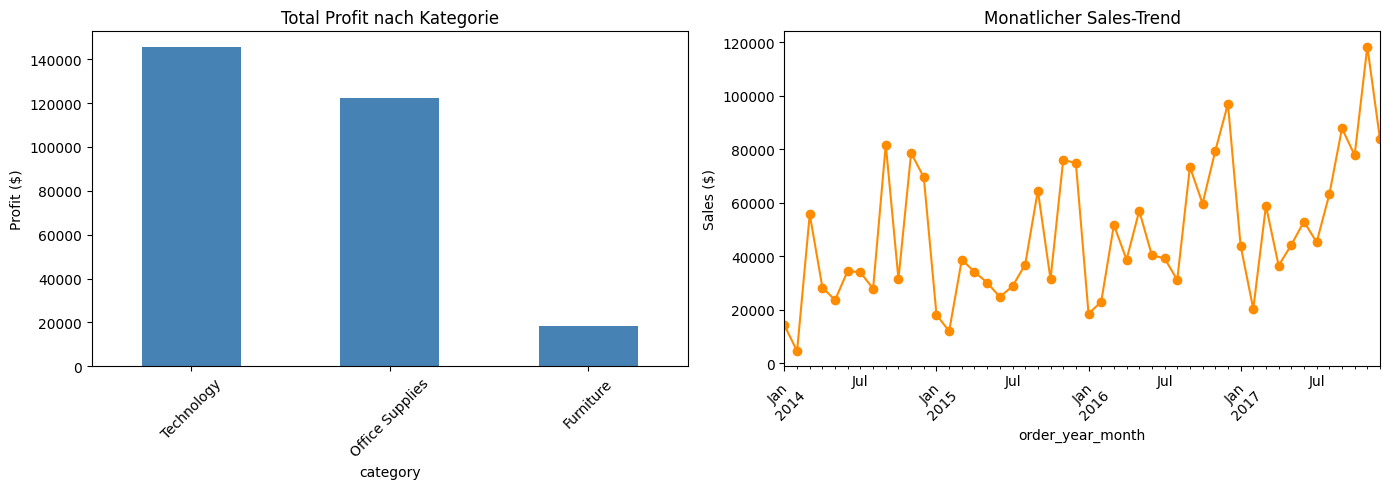

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Profit nach Kategorie
category_analysis['total_profit'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Total Profit nach Kategorie')
axes[0].set_ylabel('Profit ($)')
axes[0].tick_params(axis='x', rotation=45)

# Chart 2: Monatlicher Sales-Trend
monthly_sales = df.groupby('order_year_month')['sales'].sum()
monthly_sales.plot(kind='line', ax=axes[1], color='darkorange', marker='o')
axes[1].set_title('Monatlicher Sales-Trend')
axes[1].set_ylabel('Sales ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Fazit & Handlungsempfehlungen

**1. Furniture-Segment überarbeiten:** Die Sub-Kategorien Tables und Bookcases
erwirtschaften trotz beachtlichem Umsatz (zusammen über \$ 320K) einen
Verlust von rund \$ 21'000. Eine Überprüfung der Preisstruktur oder gezielte
Anpassung der Rabatte in diesem Bereich könnte die Profitabilität deutlich
verbessern.

**2. Rabattstrategie überdenken:** Rabattierte Bestellungen sind im Schnitt
unprofitabel (-\$ 105 statt +\$ 42 pro Auftrag). Statt pauschaler Rabatte
würde sich eine gezieltere Vergabe lohnen, z.B. begrenzt auf margenstarke
Kategorien wie Technology.

**3. Region Central braucht Aufmerksamkeit:** Mit der schwächsten Marge aller
Regionen (8% gegenüber 22% in West) lohnt sich eine genauere Untersuchung,
ob dort z.B. mehr rabattierte oder margenschwache Produkte verkauft werden.

**4. Kundenwert nicht nur am Umsatz messen:** Der Fall Sean Miller zeigt, dass
hoher Umsatz nicht gleich hoher Profit bedeutet. Ein Blick auf Profit statt
nur Umsatz bei der Kundenpriorisierung würde ein genaueres Bild liefern.

Die interaktive Visualisierung dieser Kennzahlen findet sich im begleitenden
Power BI Dashboard.

In [25]:
import sqlite3

# order_year_month in Text umwandeln, da SQLite den Pandas-'Period'-Typ nicht kennt
df['order_year_month'] = df['order_year_month'].astype(str)

conn = sqlite3.connect('superstore.db')
df.to_sql('orders', conn, if_exists='replace', index=False)

print("Datenbank erstellt. Tabelle 'orders' enthält",
      pd.read_sql("SELECT COUNT(*) as anzahl FROM orders", conn).iloc[0,0], "Zeilen")

Datenbank erstellt. Tabelle 'orders' enthält 9993 Zeilen


In [26]:
query = """
SELECT category, SUM(sales) as total_sales
FROM orders
GROUP BY category
"""
result = pd.read_sql(query, conn)
print(result)

          category  total_sales
0        Furniture       742006
1  Office Supplies       719127
2       Technology       836221


In [27]:
query1 = """
SELECT
    category,
    SUM(sales) AS total_sales,
    SUM(profit) AS total_profit,
    ROUND(AVG(profit * 100.0 / sales), 2) AS avg_margin,
    COUNT(*) AS num_orders
FROM orders
GROUP BY category
ORDER BY total_profit DESC
"""
print(pd.read_sql(query1, conn))

          category  total_sales  total_profit  avg_margin  num_orders
0       Technology       836221        145429       15.57        1847
1  Office Supplies       719127        122475       13.79        6025
2        Furniture       742006         18444        3.91        2121


In [28]:
query2 = """
SELECT
    sub_category,
    SUM(sales) AS total_sales,
    SUM(profit) AS total_profit
FROM orders
GROUP BY sub_category
ORDER BY total_profit ASC
LIMIT 5
"""
print(pd.read_sql(query2, conn))

  sub_category  total_sales  total_profit
0       Tables       206968        -17733
1    Bookcases       114879         -3479
2     Supplies        46679         -1187
3    Fasteners         3024           952
4     Machines       189243          3387


In [29]:
query3 = """
SELECT
    CASE WHEN discount = 1 THEN 'Mit Rabatt' ELSE 'Kein Rabatt' END AS discount_label,
    ROUND(AVG(profit), 2) AS avg_profit,
    ROUND(AVG(profit * 100.0 / sales), 2) AS avg_margin,
    COUNT(*) AS num_orders
FROM orders
GROUP BY discount_label
"""
print(pd.read_sql(query3, conn))

  discount_label  avg_profit  avg_margin  num_orders
0    Kein Rabatt       42.27       24.41        9072
1     Mit Rabatt     -105.41     -110.06         921


In [30]:
query4 = """
SELECT
    customer_name,
    SUM(sales) AS total_sales,
    SUM(profit) AS total_profit,
    COUNT(*) AS num_orders
FROM orders
GROUP BY customer_name
HAVING total_profit > 0
ORDER BY total_sales DESC
LIMIT 5
"""
print(pd.read_sql(query4, conn))

   customer_name  total_sales  total_profit  num_orders
0   Tamara Chand        19050          8983          12
1   Raymond Buch        15117          6976          18
2   Tom Ashbrook        14596          4704          10
3  Adrian Barton        14476          5445          20
4   Ken Lonsdale        14175           802          29


In [31]:
sql_queries = """
-- ============================================
-- Superstore Sales Analyse - SQL Queries
-- ============================================

-- Query 1: Profitabilität nach Kategorie
SELECT
    category,
    SUM(sales) AS total_sales,
    SUM(profit) AS total_profit,
    ROUND(AVG(profit * 100.0 / sales), 2) AS avg_margin,
    COUNT(*) AS num_orders
FROM orders
GROUP BY category
ORDER BY total_profit DESC;

-- Query 2: Top 5 unprofitabelste Sub-Kategorien
SELECT
    sub_category,
    SUM(sales) AS total_sales,
    SUM(profit) AS total_profit
FROM orders
GROUP BY sub_category
ORDER BY total_profit ASC
LIMIT 5;

-- Query 3: Effekt von Rabatten auf Profit
SELECT
    CASE WHEN discount = 1 THEN 'Mit Rabatt' ELSE 'Kein Rabatt' END AS discount_label,
    ROUND(AVG(profit), 2) AS avg_profit,
    ROUND(AVG(profit * 100.0 / sales), 2) AS avg_margin,
    COUNT(*) AS num_orders
FROM orders
GROUP BY discount_label;

-- Query 4: Top 5 Kunden nach Umsatz (nur profitable Kunden)
SELECT
    customer_name,
    SUM(sales) AS total_sales,
    SUM(profit) AS total_profit,
    COUNT(*) AS num_orders
FROM orders
GROUP BY customer_name
HAVING total_profit > 0
ORDER BY total_sales DESC
LIMIT 5;
"""

with open('queries.sql', 'w') as f:
    f.write(sql_queries)

print("queries.sql wurde erstellt!")

# Datei direkt herunterladen
from google.colab import files
files.download('queries.sql')

queries.sql wurde erstellt!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
df.to_csv('superstore_cleaned.csv', index=False)

from google.colab import files
files.download('superstore_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>